# Subtask 3: Post-Processing and Temporal Refinement

This notebook evaluates median filtering on Samuel's best logistic-regression system. The classifier predicts each 1-second segment independently; median filtering is applied per recording and per class to remove short isolated activations before computing the segment-based Macro F1 score.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parents[2]
sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

from src import data_io, labels
from src.config import CLASS_NAMES, SEED, TRAIN_DIR, VALIDATION_DIR, get_device
from src.features import apply_scaler, fit_scaler, select_features
from src.models import predict_proba
from src.predict import apply_thresholds
from src.postprocess import median_filter_by_recording, median_filter_segment_frame

device = get_device()
device

'cuda'

In [2]:
POST_DIR = PROJECT_ROOT / "task_andreas" / "notebooks" / "post-processing"
RESULTS_DIR = POST_DIR / "results"
FIGURES_DIR = PROJECT_ROOT / "task_andreas" / "figures"
CACHE_DIR = POST_DIR / "cache"
SAMUEL_RESULTS_DIR = PROJECT_ROOT / "task_samuel" / "results"

for path in [RESULTS_DIR, FIGURES_DIR, CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

model_candidates = sorted(SAMUEL_RESULTS_DIR.glob("02_lr_best_C*_cw*_maxiter*.joblib"))
if not model_candidates:
    model_candidates = sorted(SAMUEL_RESULTS_DIR.glob("02_lr_best_C*.joblib"))
if not model_candidates:
    raise FileNotFoundError("No Samuel LR artifact found in task_samuel/results")

MODEL_PATH = model_candidates[-1]
MODEL_PATH

WindowsPath('e:/Studium/Sem 4/ML and Pattern Classification/UE/Task 5 - Team/full_directory/task_samuel/results/02_lr_best_C0.01_cwnone_maxiter5000.joblib')

## Load the same validation split

Samuel selected and tuned the LR system on one half of the provided validation recordings, then reported the final local estimate on the other half. The split below uses the same recording-id sampling rule and keeps the hidden `test/` split untouched.

In [3]:
feature_keys = None

X_train, train_index = data_io.stack_feature_matrix(
    feature_keys,
    TRAIN_DIR,
    cache_path=CACHE_DIR / "train_features_default_seed42.npz",
)
X_validation_all, validation_index = data_io.stack_feature_matrix(
    feature_keys,
    VALIDATION_DIR,
    cache_path=CACHE_DIR / "validation_features_default_seed42.npz",
)

Y_train = labels.stack_hard_labels(
    TRAIN_DIR,
    train_index,
    cache_path=CACHE_DIR / "train_hard_labels_seed42.npy",
)
Y_validation_all = labels.stack_hard_labels(
    VALIDATION_DIR,
    validation_index,
    cache_path=CACHE_DIR / "validation_hard_labels_seed42.npy",
)

print("train", X_train.shape, Y_train.shape)
print("validation all", X_validation_all.shape, Y_validation_all.shape)

train (170508, 960) (170508, 15)
validation all (47050, 960) (47050, 15)


In [4]:
validation_index_df = pd.DataFrame(validation_index)
recording_ids = pd.Series(validation_index_df["recording_id"].unique())
local_val_recordings = recording_ids.sample(frac=0.5, random_state=SEED)
is_local_val = validation_index_df["recording_id"].isin(local_val_recordings).to_numpy()

X_val = X_validation_all[is_local_val]
Y_val = Y_validation_all[is_local_val]
val_index = validation_index_df.loc[is_local_val].reset_index(drop=True)

X_nht = X_validation_all[~is_local_val]
Y_nht = Y_validation_all[~is_local_val]
nht_index = validation_index_df.loc[~is_local_val].reset_index(drop=True)

print("local validation", X_val.shape, Y_val.shape, val_index["filename"].nunique(), "recordings")
print("non-hidden test", X_nht.shape, Y_nht.shape, nht_index["filename"].nunique(), "recordings")

local validation (23734, 960) (23734, 15) 500 recordings
non-hidden test (23316, 960) (23316, 15) 499 recordings


## Rebuild preprocessing and predict

Samuel's saved model artifact contains the LR model and thresholds. The scaler is rebuilt from the official training split only, matching the original notebook and avoiding leakage from the local validation or non-hidden test subsets.

In [5]:
preprocess_path = CACHE_DIR / "lr_preprocessing_rebuilt_train_only_seed42.joblib"
if preprocess_path.exists():
    preprocessing = joblib.load(preprocess_path)
    scaler = preprocessing["scaler"]
    selector = preprocessing["selector"]
else:
    scaler = fit_scaler(X_train)
    X_train_scaled = apply_scaler(scaler, X_train)
    selector, _ = select_features(X_train_scaled, Y_train, method="none")
    joblib.dump({"scaler": scaler, "selector": selector}, preprocess_path)

X_nht_model = selector.transform(apply_scaler(scaler, X_nht))

artifacts = joblib.load(MODEL_PATH)
model = artifacts["model"]
thresholds = artifacts.get("thresholds")
if thresholds is None:
    threshold_df = pd.read_csv(SAMUEL_RESULTS_DIR / "02_lr_best_thresholds.csv")
    thresholds = dict(zip(threshold_df["class_name"], threshold_df["threshold"]))

prob_nht = predict_proba(model, X_nht_model)
pred_nht = apply_thresholds(prob_nht, thresholds, CLASS_NAMES)

baseline_macro = f1_score(Y_nht, pred_nht, average="macro", zero_division=0)
baseline_micro = f1_score(Y_nht, pred_nht, average="micro", zero_division=0)
baseline_macro, baseline_micro

(0.54063355742308, 0.6198659130952109)

## Median-filter window sweep

Median filtering is applied after thresholding. Window size `1` is the unprocessed reference system. Larger odd windows remove increasingly long isolated detections, but can also erase genuinely short sound events.

In [6]:
window_sizes = [1, 3, 5, 7, 9, 11]
rows = []
per_class_rows = []

for window in window_sizes:
    filtered = median_filter_by_recording(pred_nht, nht_index, window=window)
    per_class_f1 = f1_score(Y_nht, filtered, average=None, zero_division=0)
    rows.append(
        {
            "window": window,
            "macro_f1": f1_score(Y_nht, filtered, average="macro", zero_division=0),
            "micro_f1": f1_score(Y_nht, filtered, average="micro", zero_division=0),
            "active_segments": int(filtered.sum()),
        }
    )
    per_class_rows.extend(
        {"window": window, "class_name": class_name, "f1": float(score)}
        for class_name, score in zip(CLASS_NAMES, per_class_f1)
    )

sweep_df = pd.DataFrame(rows)
per_class_df = pd.DataFrame(per_class_rows)
best_window = int(sweep_df.sort_values("macro_f1", ascending=False).iloc[0]["window"])

sweep_df.to_csv(RESULTS_DIR / "03_median_filter_window_sweep.csv", index=False)
per_class_df.to_csv(RESULTS_DIR / "03_median_filter_per_class_f1.csv", index=False)

display(sweep_df)
best_window

,window,macro_f1,micro_f1,active_segments
0,1,0.540634,0.619866,22331
1,3,0.556992,0.643497,20493
2,5,0.559064,0.655086,18522
3,7,0.550189,0.654459,17457
4,9,0.530825,0.647934,16601
5,11,0.513126,0.636149,15918


5

In [7]:
reference = per_class_df[per_class_df["window"] == 1][["class_name", "f1"]].rename(columns={"f1": "without_postprocessing"})
best = per_class_df[per_class_df["window"] == best_window][["class_name", "f1"]].rename(columns={"f1": "with_postprocessing"})
comparison_df = reference.merge(best, on="class_name")
comparison_df["delta"] = comparison_df["with_postprocessing"] - comparison_df["without_postprocessing"]
comparison_df = comparison_df.sort_values("delta", ascending=False).reset_index(drop=True)
comparison_df.to_csv(RESULTS_DIR / "03_median_filter_best_window_class_comparison.csv", index=False)
display(comparison_df)

,class_name,without_postprocessing,with_postprocessing,delta
0,wardrobe_drawer_open_close,0.356898,0.419355,0.062457
1,keyboard_typing,0.713185,0.769162,0.055977
2,coffee_machine,0.496825,0.540825,0.044000
3,toilet_flushing,0.575325,0.611189,0.035864
4,bell_ringing,0.540804,0.575305,0.034501
5,footsteps,0.574573,0.608767,0.034194
6,microwave,0.710436,0.742636,0.032200
7,phone_ringing,0.678073,0.704018,0.025945
8,light_switch,0.221607,0.245810,0.024203
9,running_water,0.785624,0.806112,0.020488


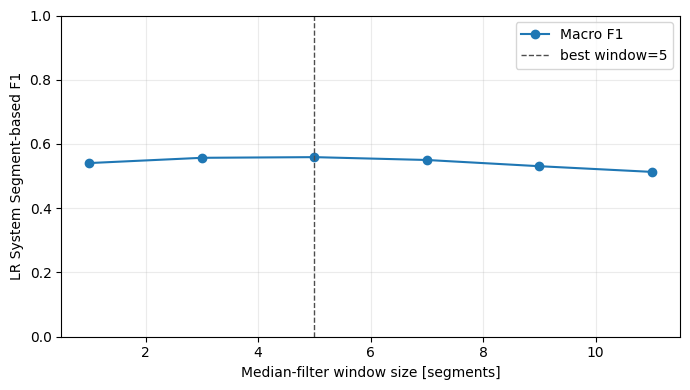

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep_df["window"], sweep_df["macro_f1"], marker="o", label="Macro F1")
# ax.plot(sweep_df["window"], sweep_df["micro_f1"], marker="s", label="Micro F1")
ax.axvline(best_window, color="0.3", linestyle="--", linewidth=1, label=f"best window={best_window}")
ax.set_xlabel("Median-filter window size [segments]")
ax.set_ylabel("LR System Segment-based F1")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "postprocessing_lr_median_filter_window_sweep.png", dpi=150)
plt.show()

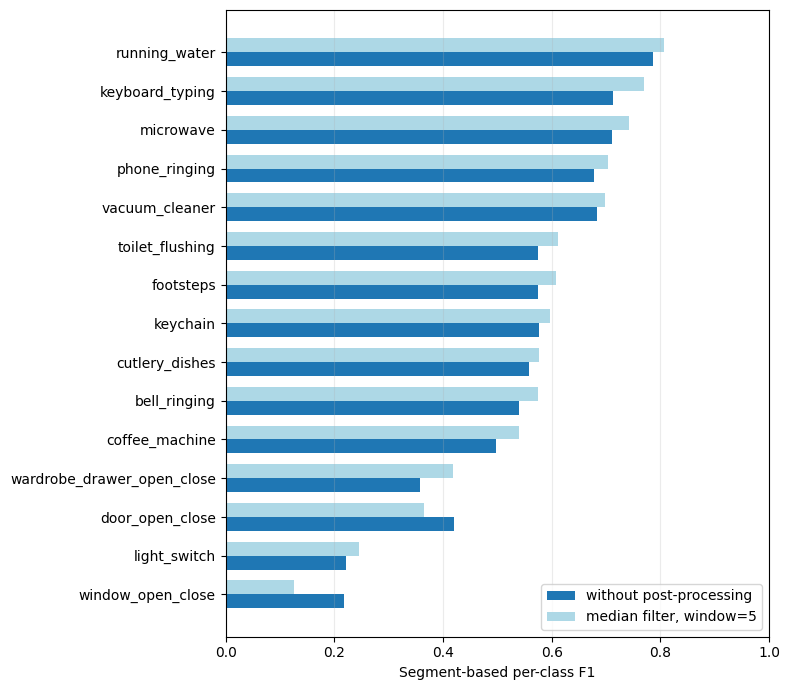

In [16]:
plot_df = comparison_df.sort_values("with_postprocessing")
y = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(y - 0.18, plot_df["without_postprocessing"], height=0.36, label="without post-processing", color="tab:blue")
ax.barh(y + 0.18, plot_df["with_postprocessing"], height=0.36, label=f"median filter, window={best_window}", color="lightblue")
ax.set_yticks(y)
ax.set_yticklabels(plot_df["class_name"])
ax.set_xlabel("Segment-based per-class F1")
ax.set_xlim(0, 1)
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "postprocessing_lr_median_filter_per_class_comparison.png", dpi=150)
plt.show()

## Baseline decision-tree comparison

The same median-filter sweep is also applied to the reproduced decision-tree baseline from `task_andreas/notebooks/baseline`. These predictions are already saved as interval CSVs, so the cells below use the baseline evaluator to convert intervals to one-second segment frames before filtering.

In [10]:
import importlib.util

BASELINE_DIR = PROJECT_ROOT / "task_andreas" / "notebooks" / "baseline"
BASELINE_OUTPUT_DIR = BASELINE_DIR / "evaluation_outputs"
GT_NHT_CSV = BASELINE_OUTPUT_DIR / "ground_truth_non_hidden_test.csv"
PRED_NHT_CSV = BASELINE_OUTPUT_DIR / "predictions_non_hidden_test.csv"

spec = importlib.util.spec_from_file_location("baseline_evaluate", BASELINE_DIR / "evaluate.py")
baseline_evaluate = importlib.util.module_from_spec(spec)
sys.modules["baseline_evaluate"] = baseline_evaluate
spec.loader.exec_module(baseline_evaluate)

gt_raw = baseline_evaluate.load_annotation_csv(GT_NHT_CSV, ground_truth=True)
pred_intervals = baseline_evaluate.load_annotation_csv(PRED_NHT_CSV, ground_truth=False)
gt_intervals = baseline_evaluate.aggregate_ground_truth_annotations(gt_raw)

gt_segments = baseline_evaluate.build_segment_frame_from_intervals(gt_intervals, name="ground_truth")
baseline_pred_segments = baseline_evaluate.build_segment_frame_from_intervals(pred_intervals, name="predictions")
baseline_reference_index = gt_segments.index.union(baseline_pred_segments.index)

baseline_macro_check, baseline_results_check = baseline_evaluate.calculate_f1_score(gt_segments, baseline_pred_segments)
baseline_macro_check

0.3169890060259231

In [11]:
baseline_rows = []
baseline_per_class_rows = []

for window in window_sizes:
    filtered_segments = median_filter_segment_frame(
        baseline_pred_segments,
        window=window,
        class_names=CLASS_NAMES,
        reference_index=baseline_reference_index,
    )
    macro_f1, class_results = baseline_evaluate.calculate_f1_score(gt_segments, filtered_segments)
    baseline_rows.append(
        {
            "window": window,
            "macro_f1": macro_f1,
            "active_segments": int(filtered_segments[CLASS_NAMES].to_numpy().sum()),
        }
    )
    baseline_per_class_rows.extend(
        {
            "window": window,
            "class_name": row.annotation,
            "precision": row.precision,
            "recall": row.recall,
            "f1": row.f1,
        }
        for row in class_results.itertuples(index=False)
    )

baseline_sweep_df = pd.DataFrame(baseline_rows)
baseline_per_class_df = pd.DataFrame(baseline_per_class_rows)
baseline_best_window = int(baseline_sweep_df.sort_values("macro_f1", ascending=False).iloc[0]["window"])

baseline_sweep_df.to_csv(RESULTS_DIR / "03_baseline_median_filter_window_sweep.csv", index=False)
baseline_per_class_df.to_csv(RESULTS_DIR / "03_baseline_median_filter_per_class_f1.csv", index=False)

display(baseline_sweep_df)
baseline_best_window

,window,macro_f1,active_segments
0,1,0.316989,11335
1,3,0.301404,6681
2,5,0.276303,5324
3,7,0.255665,4632
4,9,0.242278,4207
5,11,0.222855,3877


1

In [12]:
baseline_reference = baseline_per_class_df[baseline_per_class_df["window"] == 1][["class_name", "f1"]].rename(columns={"f1": "without_postprocessing"})
baseline_window3 = baseline_per_class_df[baseline_per_class_df["window"] == 3][["class_name", "f1"]].rename(columns={"f1": "window3_postprocessing"})
baseline_class_comparison_df = baseline_reference.merge(baseline_window3, on="class_name")
baseline_class_comparison_df["delta"] = baseline_class_comparison_df["window3_postprocessing"] - baseline_class_comparison_df["without_postprocessing"]
baseline_class_comparison_df = baseline_class_comparison_df.sort_values("delta", ascending=False).reset_index(drop=True)
baseline_class_comparison_df.to_csv(RESULTS_DIR / "03_baseline_median_filter_window3_class_comparison.csv", index=False)
display(baseline_class_comparison_df)

,class_name,without_postprocessing,window3_postprocessing,delta
0,vacuum_cleaner,0.469742,0.520791,0.051048
1,microwave,0.389610,0.437987,0.048377
2,keyboard_typing,0.358953,0.393217,0.034264
3,phone_ringing,0.484848,0.518932,0.034084
4,running_water,0.577570,0.611210,0.033641
5,toilet_flushing,0.290353,0.315259,0.024905
6,bell_ringing,0.288235,0.281588,-0.006647
7,coffee_machine,0.362007,0.350051,-0.011956
8,keychain,0.321149,0.300643,-0.020506
9,cutlery_dishes,0.287251,0.248927,-0.038324


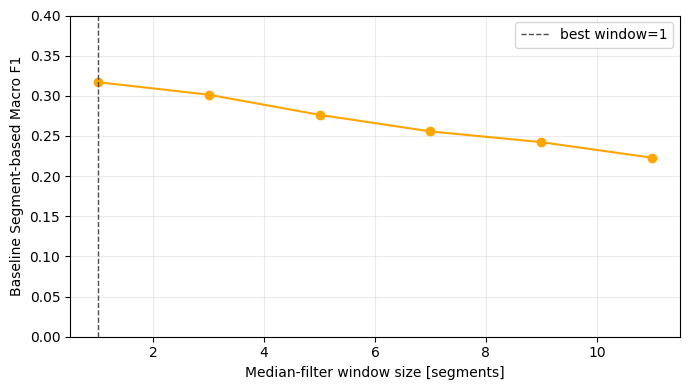

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(baseline_sweep_df["window"], baseline_sweep_df["macro_f1"], marker="o", color="orange")
ax.axvline(baseline_best_window, color="0.3", linestyle="--", linewidth=1, label=f"best window={baseline_best_window}")
ax.set_xlabel("Median-filter window size [segments]")
ax.set_ylabel("Baseline Segment-based Macro F1")
ax.set_ylim(0, 0.4)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "postprocessing_baseline_median_filter_window_sweep.png", dpi=150)
plt.show()

## LR quantitative comparison

Median filtering improved the non-hidden-test score of Samuel's LR system. Without post-processing, the Segment-based Macro F1 was **0.5406** and the Micro F1 was **0.6199**. The best tested median-filter setting was a **5-segment window**, which increased Macro F1 to **0.5591** and Micro F1 to **0.6551**.

This is an absolute Macro F1 gain of **+0.0184** points. The number of predicted active segments also dropped from **22,331** to **18,522**, which indicates that the filter removed many short isolated activations.

## LR effect of the window size

The parameter sweep shows that a small amount of temporal refinement is helpful, but too much smoothing becomes harmful. Window size **3** already improved Macro F1 to **0.5570**, and window size **5** performed best with **0.5591**. Larger windows then reduced performance: window **7** fell to **0.5502**, window **9** to **0.5308**, and window **11** to **0.5131**.

This pattern is consistent with the expected behavior of median filtering. Small windows remove one-off prediction spikes while preserving most true events. Larger windows become too aggressive and can suppress real short events or shift event boundaries enough to hurt the segment-based metric.

## LR per-class effects

Most classes improved with the best 5-segment median filter. The largest gains were for **wardrobe_drawer_open_close** (+0.0625 F1), **keyboard_typing** (+0.0560), **coffee_machine** (+0.0440), **toilet_flushing** (+0.0359), **bell_ringing** (+0.0345), and **footsteps** (+0.0342). These gains suggest that the original independent segment classifier produced noisy short gaps or short false activations that could be corrected by looking at neighboring segments.

The strongest degradations were for **window_open_close** (-0.0912 F1) and **door_open_close** (-0.0537). These are short, transient events, so a median filter can remove true positives if the event is active for only a small number of neighboring segments. This explains why the overall Macro F1 improves, but not every class benefits.

## Baseline interpretation

The decision-tree baseline does **not** benefit from median filtering. Its best result remains the unprocessed output with Macro F1 **0.3170**. The mildest post-processing setting, window size **3**, lowers Macro F1 to **0.3014** even though Micro F1 increases slightly from **0.3630** to **0.3724**. Larger windows are increasingly harmful: window **5** drops to **0.2763**, window **7** to **0.2557**, window **9** to **0.2423**, and window **11** to **0.2229**.

The window-3 class comparison shows why the macro score falls. Some longer or more stable events improve, especially **vacuum_cleaner** (+0.0510 F1), **microwave** (+0.0484), **keyboard_typing** (+0.0343), **phone_ringing** (+0.0341), and **running_water** (+0.0336). However, the filter strongly hurts short or sparse event classes such as **light_switch** (-0.1254), **door_open_close** (-0.0949), **wardrobe_drawer_open_close** (-0.0841), and **window_open_close** (-0.0396). Because Macro F1 weights every class equally, these losses dominate the baseline result.

## Overall conclusion

Median filtering has different effects depending on the underlying classifier. For the stronger LR system, a moderate **5-segment** filter reduces noisy isolated predictions and improves Segment-based Macro F1 from **0.5406** to **0.5591**. For the weaker decision-tree baseline, the unprocessed predictions are best; median filtering removes too many true positives from short event classes and reduces Macro F1 from **0.3170** to **0.3014** even with the smallest tested post-processing window.

The main takeaway is that temporal refinement is useful when the classifier already produces reasonably coherent event regions with occasional local noise. When predictions are sparse or fragmented, as in the baseline, median filtering can over-suppress short events and degrade the macro-averaged score.